# Set up : normal , preprocessed , preprocessed_balanced

### **All Libraries**

In [1]:
# === Standard Libraries ===
import string
import re
import time

# === Data Handling ===
import pandas as pd

# === Text Vectorization ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# === Model Training & Evaluation ===
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC, NuSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.utils import resample

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === NLP & Preprocessing ===
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem.isri import ISRIStemmer

# === NLTK Downloads (Run once) ===
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### **Preparation du fichier / Analyse**

In [2]:
df = pd.read_csv("ASTD_RAW.csv", encoding="utf-8")

# Find the number of duplicate rows based on the 'Text' column
duplicates_count = df.duplicated(subset="Text").sum()

# Remove duplicate rows based on the 'Text' column
df = df.drop_duplicates(subset="Text", keep="first")

# Print the results
print(f"{duplicates_count} duplicate rows were deleted.")

4 duplicate rows were deleted.


Sentiment Distribution:
 Label
OBJ        6466
NEG        1642
NEUTRAL     805
POS         777
Name: count, dtype: int64


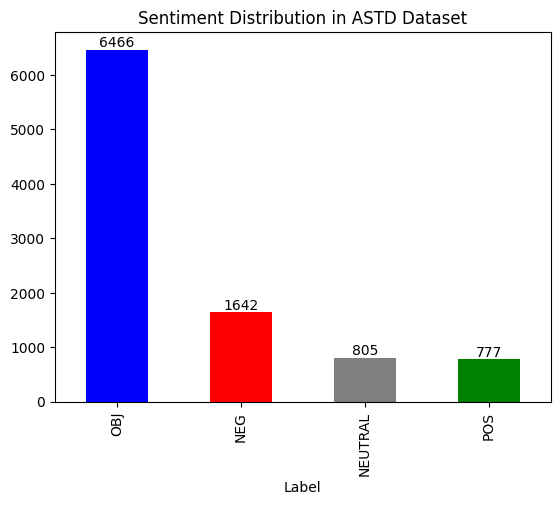

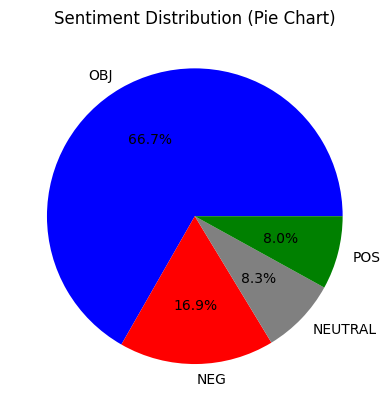

In [3]:
# Count sentiment occurrences
sentiment_counts = df["Label"].value_counts()
print("Sentiment Distribution:\n", sentiment_counts)

# Define colors for the 4 ratings
colors = ["blue", "red", "gray", "green"]

# Bar Chart
ax = sentiment_counts.plot(kind="bar", color=colors)
plt.title("Sentiment Distribution in ASTD Dataset")

# Add the exact number on top of each bar
for i, v in enumerate(sentiment_counts):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=10)  # Adjust vertical position if needed

#plt.savefig("bar_chart.png")
plt.show()

# Pie Chart
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", colors=colors)
plt.title("Sentiment Distribution (Pie Chart)")
plt.ylabel("")
#plt.savefig("pie_chart.png")
print("\n")
plt.show()


In [4]:
# Filter out OBJ and NEUTRAL sentiments
df = df[df["Label"].isin(["POS", "NEG"])]

# Print summary
print("New Sentiment Distribution:")
print(df["Label"].value_counts())

New Sentiment Distribution:
Label
NEG    1642
POS     777
Name: count, dtype: int64


Sentiment Distribution:
 Label
NEG    1642
POS     777
Name: count, dtype: int64


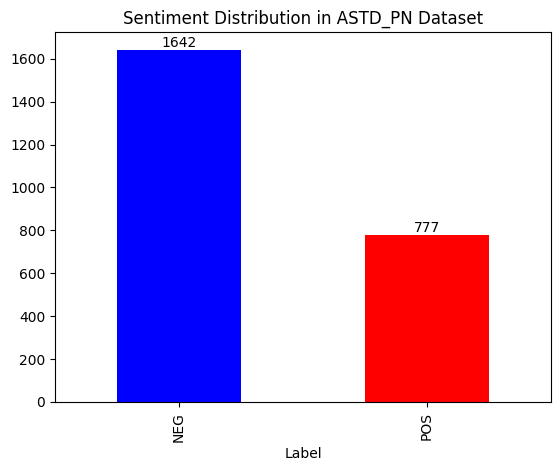

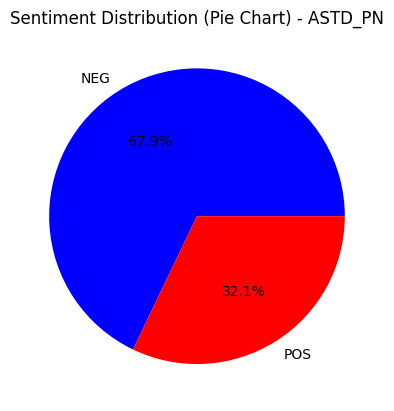

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
#df = pd.read_csv("ASTD_PN.csv", encoding="utf-8")

# Count sentiment occurrences
sentiment_counts = df["Label"].value_counts()
print("Sentiment Distribution:\n", sentiment_counts)

# Define colors for the 2 ratings
colors = ["blue", "red"]

# Bar Chart
ax = sentiment_counts.plot(kind="bar", color=colors)
plt.title("Sentiment Distribution in ASTD_PN Dataset")

# Add the exact number on top of each bar
for i, v in enumerate(sentiment_counts):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=10)  # Adjust vertical position if needed

#plt.savefig("bar_chart_pn.png")
plt.show()

# Pie Chart
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", colors=colors)
plt.title("Sentiment Distribution (Pie Chart) - ASTD_PN")
plt.ylabel("")
#plt.savefig("pie_chart_pn.png")
print("\n")
plt.show()


In [6]:
# Replace POS with 1 and NEG with 0 in the 'Label' column
df["Label"] = df["Label"].replace({"POS": 1, "NEG": 0})

# Save the new dataset
df.to_csv("ASTD.csv", index=False, encoding="utf-8")

# Print the first few rows to verify
print("Updated dataset saved as ASTD.csv")


Updated dataset saved as ASTD.csv


<ipython-input-6-25cfcb4c7c90>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Label"] = df["Label"].replace({"POS": 1, "NEG": 0})


### **Pretraitement**

In [7]:
import pandas as pd
import string
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.isri import ISRIStemmer
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
def remove_non_arabic(text):
    if isinstance(text, str):
        return re.sub(r'[^\u0620-\u064A\s]', ' ', text)
    return ''

def tokenization(text):
    if isinstance(text, str):
        return re.findall(r'\S+', text)  # Matches sequences of non-space characters
    return []

def remove_arabic_stopwords(tokens):
    arabic_stopwords = set(stopwords.words("arabic"))  # Convert to set for faster lookup
    return [token for token in tokens if token not in arabic_stopwords]

def get_root(word, stemmer):
    if isinstance(word, str):
        return stemmer.stem(word)
    return word

def stemming_AR(tokens):
    stemmer = ISRIStemmer()
    return [get_root(token, stemmer) for token in tokens]

def rejoin_tokens(tokens):
    filtered_tokens = [token for token in tokens if isinstance(token, str) and token.strip()]
    return ' '.join(filtered_tokens)

In [9]:
def ASTD_pretraitement(text):
    if isinstance(text, str):

        # Step 1: Remove non-arabic characters
        text = remove_non_arabic(text)

        # Step 2: Tokenization (split text into tokens)
        tokens = tokenization(text)

        # Step 3: Remove Arabic stopwords
        tokens = remove_arabic_stopwords(tokens)

        # Step 4: Apply stemming (ISRI Stemmer for Arabic)
        tokens = stemming_AR(tokens)

        # Step 5: Rejoin tokens into a single string
        return rejoin_tokens(tokens)

    return ''

In [10]:
print(f"Start processing ASTD ...\n")
ASTD = pd.read_csv("/content/ASTD.csv")
ASTD["Text"] = [ASTD_pretraitement(text) for text in df["Text"]]
ASTD.to_csv("/content/ASTD_Pre.csv", index=False)
print(f"Finished processing ASTD!\n")

Start processing ASTD ...

Finished processing ASTD!



### **Balancing**

In [11]:
from sklearn.utils import resample
import pandas as pd

# Load your original dataset
df = pd.read_csv('ASTD_Pre.csv', encoding='utf-8-sig')

# Drop NaNs
df = df.dropna(subset=['Text']).reset_index(drop=True)

# Separate classes
df_majority = df[df['Label'] == 0]
df_minority = df[df['Label'] == 1]

# Oversample minority
df_minority_oversampled = resample(df_minority,
                                   replace=True,
                                   n_samples=len(df_majority),
                                   random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_majority, df_minority_oversampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
df_balanced.to_csv('ASTD_Pre_Blc.csv', index=False, encoding='utf-8-sig')

print("Balanced text data saved to 'ASTD_Pre_Blc.csv'")

Balanced text data saved to 'ASTD_Pre_Blc.csv'


# Set up : Algorithms Functions

### Libraries

In [12]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

### **Visualisation / Metrics**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_visualize_results(results):
    cm = results["Confusion Matrix"]
    title = f"{results['Dataset']} with {results['Algorithm']}"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1, 1.1]})
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Heatmap sans lignes internes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                square=True, linewidths=0, annot_kws={"size": 11})
    ax1.set_xlabel('Predicted Label', fontsize=11)
    ax1.set_ylabel('True Label', fontsize=11)
    ax1.set_title('Confusion Matrix', fontsize=12)
    ax1.set_xticklabels(['Negative', 'Positive'], fontsize=10)
    ax1.set_yticklabels(['Negative', 'Positive'], fontsize=10)

    # ✅ Cadre très fin autour de toute la matrice
    for _, spine in ax1.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')

    ax2.axis('off')
    ax2.set_title('Overall Performance', fontsize=12, fontweight='bold', loc='left')

    metrics_list = [
        ("Accuracy", results['Accuracy']),
        ("Macro F1", results['Macro F1']),
        ("Weighted F1", results['Weighted F1']),
        ("Execution Time (s)", results['Execution Time (s)']),
        ("# Positive Samples", results['Number of Positive Samples']),
        ("# Negative Samples", results['Number of Negative Samples'])
    ]

    y_text = 0.95
    for name, value in metrics_list:
        ax2.text(0.01, y_text, f"{name}: {value}", fontsize=11, va='top')
        y_text -= 0.11

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()


### **Vectorize**

In [14]:
import time
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

def vectorize_text_data(csv_path, sample_percentage=1.0):
    # === Load dataset
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df = df[df['Text'].notna() & (df['Text'] != "")]

    if sample_percentage < 1.0:
        df = df.sample(frac=sample_percentage, random_state=42).reset_index(drop=True)

    X = df['Text']
    y = df['Label']

    # === Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # === Vectorize
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # === Save vectorizer
    os.makedirs("models", exist_ok=True)
    base_name = os.path.splitext(os.path.basename(csv_path))[0]
    vec_path = f"models/tfidf_vectorizer_{base_name}.pkl"
    joblib.dump(vectorizer, vec_path)
    print(f"✅ Vectorizer saved to: {vec_path}")

    return X_train_tfidf, X_test_tfidf, y_train, y_test, df


### **Traitement**

In [15]:
import time
from sklearn.metrics import (
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    roc_auc_score, confusion_matrix
)

def run_model_on_vectorized_data(X_train_tfidf, X_test_tfidf, y_train, y_test, df,
                                 model_class, model_name, dataset_name, model_params=None):
    # === Training & Prediction
    model = model_class(**(model_params or {}))
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    execution_time = time.time() - start_time
    cm = confusion_matrix(y_test, y_pred)

    # === Metrics
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test_tfidf)[:, 1])
    except:
        auc = None

    results = {
        "Dataset": dataset_name,
        "Algorithm": model_name,
        "Confusion Matrix": cm,
        "Accuracy": round(balanced_acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "ROC AUC": round(auc, 4) if auc is not None else "N/A",
        "Execution Time (s)": round(execution_time, 4),
        "Number of Positive Samples": len(df[df['Label'] == 1]),
        "Number of Negative Samples": len(df[df['Label'] == 0]),
        "y_test": y_test,
        "y_pred": y_pred
    }

    analyze_and_visualize_results(results)
    return results


### **Traitement (optimized)**

In [32]:
import os
import time
import joblib
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score
)

def optimize_and_run_model(X_train_tfidf, X_test_tfidf, y_train, y_test, df,
                           model_class, param_grid, model_name, dataset_name):
    print(f"⚡ Testing for {model_name} on {dataset_name}...")

    best_macro_f1 = -1
    best_params = None
    best_model = None
    best_y_pred = None
    best_y_proba = None
    execution_time = 0

    param_name = list(param_grid.keys())[0]
    param_values = param_grid[param_name]

    for val in param_values:
        current_params = {param_name: val}
        model = model_class(**current_params)

        start = time.time()
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)
        duration = time.time() - start

        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_params = current_params
            best_model = model
            best_y_pred = y_pred
            execution_time = duration

            # Try to get probability for ROC AUC
            try:
                best_y_proba = model.predict_proba(X_test_tfidf)[:, 1]
            except AttributeError:
                best_y_proba = None

    print(f"✅ Best {param_name} = {best_params[param_name]} → Macro F1: {best_macro_f1:.4f}")

    os.makedirs("models", exist_ok=True)
    model_path = f"models/{model_name}_{dataset_name}_best.pkl"
    joblib.dump(best_model, model_path)
    print(f"📦 Model saved to: {model_path}")

    cm = confusion_matrix(y_test, best_y_pred)
    weighted_f1 = f1_score(y_test, best_y_pred, average="weighted", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, best_y_pred)

    if best_y_proba is not None:
        try:
            auc = roc_auc_score(y_test, best_y_proba)
        except ValueError:
            auc = None
    else:
        auc = None

    results = {
        "Dataset": dataset_name,
        "Algorithm": model_name,
        "Confusion Matrix": cm,
        "Accuracy": round(balanced_acc, 4),
        "Macro F1": round(best_macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "ROC AUC": round(auc, 4) if auc is not None else "N/A",
        "Execution Time (s)": round(execution_time, 4),
        "Number of Positive Samples": len(df[df['Label'] == 1]),
        "Number of Negative Samples": len(df[df['Label'] == 0]),
        "Best Params": best_params,
        "y_test": y_test,
        "y_pred": best_y_pred,
        "y_proba": best_y_proba  # ✅ Needed for ROC curve plotting
    }

    analyze_and_visualize_results(results)
    return results


### **Hyper Parameter Testing Function (one datasets)**

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import matplotlib.patheffects as path_effects

def test_model_with_param_from_vectorized_data(
    X_train_tfidf, X_test_tfidf, y_train, y_test, df,
    model_class, param_name, param_values, dataset_label="Dataset",
    base_color="steelblue", lighter_color=None
):
    print("\n\n=== Default Run ===\n")
    default_result = run_model_on_vectorized_data(
        X_train_tfidf, X_test_tfidf, y_train, y_test, df,
        model_class=model_class,
        model_name=f"{model_class.__name__} (default)",
        dataset_name=dataset_label
    )
    default_macro_f1 = default_result["Macro F1"]

    print("\n\n=== Parameter Tuning ===\n")
    macro_f1_scores = []
    valid_values = []

    for val in param_values:
        try:
            model = model_class(**{param_name: val})
            model.fit(X_train_tfidf, y_train)
            y_pred = model.predict(X_test_tfidf)
            macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
            valid_values.append(val)
            macro_f1_scores.append(macro_f1)
            print(f"{param_name} = {val} → Macro F1 = {round(macro_f1, 4)}")
        except Exception as e:
            print(f"Skipped {param_name} = {val} due to error: {e}")

    print("\n\n=== Plot: Macro F1 vs Parameter ===\n")
    plt.figure(figsize=(7, 4))
    plt.plot(valid_values, macro_f1_scores, marker='o', linestyle='--', color=base_color)
    plt.title(f"{model_class.__name__} on {dataset_label}\nMacro F1 vs {param_name}", fontsize=13)
    plt.xlabel(param_name)
    plt.ylabel("Macro F1")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_index = macro_f1_scores.index(max(macro_f1_scores))
    best_param_value = valid_values[best_index]

    print("\n\n=== Final Run with Best Parameter ===\n")
    best_result = run_model_on_vectorized_data(
        X_train_tfidf, X_test_tfidf, y_train, y_test, df,
        model_class=model_class,
        model_name=f"{model_class.__name__} (best {param_name}={best_param_value})",
        dataset_name=dataset_label,
        model_params={param_name: best_param_value}
    )
    best_macro_f1 = best_result["Macro F1"]

    print("\n\n=== Comparison Plot (Horizontal) ===\n")
    labels = ['Default', 'Tuned']
    macro_f1_vals = [default_macro_f1, best_macro_f1]
    y = range(len(labels))
    width = 0.4

    # Use lightened and normal colors
    lighter = lighter_color if lighter_color else "lightgray"
    darker = base_color

    plt.figure(figsize=(6, 2.8))
    bars = plt.barh(y, macro_f1_vals, height=width, color=[lighter, darker])
    for i, bar in enumerate(bars):
        width_val = bar.get_width()
        # Format to 2 decimal places and add white border around text
        text = plt.text(width_val + 0.01, bar.get_y() + bar.get_height()/2.,
                       f'{width_val:.2f}', va='center', fontsize=9)
        # Add white border/outline effect
        text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])

    plt.yticks(ticks=y, labels=labels)
    plt.xlim(0, 1)
    plt.xlabel("Macro F1 Score")
    plt.title(f"{model_class.__name__} - Macro F1 Before vs After Tuning")
    plt.tight_layout()
    plt.show()

    return {
        "Dataset": dataset_label,
        "Model": model_class.__name__,
        "Param Name": param_name,
        "Default Value": "default",
        "Best Value": best_param_value,
        "Macro F1 (Default)": round(default_macro_f1, 4),
        "Macro F1 (Tuned)": round(best_macro_f1, 4),
        "Color": base_color
    }

### **test Algorithm 3 Vdatasets**

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def evaluate_model_with_plot(datasets, model_class, param_name, param_values):
    results_list = []
    roc_data = []

    # Handle LinearSVC naming manually
    is_linear_svc = model_class.__name__ == "LinearSVC"
    model_name = "LinearSVC" if is_linear_svc else model_class.__name__

    print(f"\n🔎 Evaluating {model_name} with param: {param_name} ∈ {param_values}")

    param_grid = {param_name: param_values}

    for dataset_name, (X_train, X_test, y_train, y_test, df) in datasets.items():
        print(f"\n🚀 Running {model_name} on {dataset_name}...")

        # Wrap LinearSVC internally if needed
        if is_linear_svc:
            def wrapped_model_class(**params):
                base_model = LinearSVC(**params, max_iter=10000)
                return CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
            result_model_class = wrapped_model_class
        else:
            result_model_class = model_class

        result = optimize_and_run_model(
            X_train_tfidf=X_train,
            X_test_tfidf=X_test,
            y_train=y_train,
            y_test=y_test,
            df=df,
            model_class=result_model_class,
            param_grid=param_grid,
            model_name=model_name,
            dataset_name=dataset_name
        )

        result_flat = {
            "Dataset": result["Dataset"],
            "Algorithm": result["Algorithm"],
            "Macro F1": result["Macro F1"],
            "Weighted F1": result["Weighted F1"],
            "Accuracy": result["Accuracy"],
            "ROC AUC": result["ROC AUC"],
            "Execution Time (s)": result["Execution Time (s)"],
            "# Positive Samples": result["Number of Positive Samples"],
            "# Negative Samples": result["Number of Negative Samples"],
            "Best Params": result["Best Params"]
        }

        results_list.append(result_flat)

        # Store ROC data if available
        if result["y_proba"] is not None:
            fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
            roc_auc = auc(fpr, tpr)
            roc_data.append((dataset_name, fpr, tpr, roc_auc))

    # === Results Table
    df_results = pd.DataFrame(results_list)

    # === F1 Bar Plot
    print("\n\n")
    base_colors = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#FF7F3F', '#9D4EDD']
    datasets_names = df_results['Dataset']
    scores = df_results['Macro F1']
    colors = base_colors[:len(scores)]

    plt.figure(figsize=(7, 4))
    bar_width = 0.2
    x_pos = [i * (bar_width + 0.01) for i in range(len(scores))]
    bars = plt.bar(x_pos, scores, color=colors, width=bar_width)

    for i, bar in enumerate(bars):
        yval = bar.get_height()
        text = plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.01,
            f"{yval:.3f}",
            ha='center',
            fontsize=10,
            color='black'
        )
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

    plt.xticks([])
    legend_elements = [Patch(facecolor=colors[i], label=datasets_names[i]) for i in range(len(datasets_names))]
    plt.legend(handles=legend_elements, title="Datasets", loc="center left", bbox_to_anchor=(1.02, 0.5),
               fontsize=9, title_fontsize=10, frameon=True)

    plt.title(f"Macro F1 Score by Dataset ({model_name})", fontsize=13, fontweight='bold')
    plt.ylabel("Macro F1 Score")
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
    print("\n\n")
    # === ROC Curve Plot
    if roc_data:
        plt.figure(figsize=(7, 5))
        dataset_to_color = dict(zip(datasets_names, colors))
        for name, fpr, tpr, roc_auc in roc_data:
            color = dataset_to_color.get(name, None)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})', color=color)

        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves - {model_name}')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df_results


### **All tuning results**

In [19]:
import matplotlib.pyplot as plt

def plot_all_models_comparison(summary_df):
    models = summary_df["Model"]
    default_scores = summary_df["Macro F1 (Default)"]
    tuned_scores = summary_df["Macro F1 (Tuned)"]
    best_params = summary_df["Best Value"]
    param_names = summary_df["Param Name"]
    colors = summary_df["Color"]  # base color per model

    # Manual dictionary mapping for default values
    default_values = {
        "MultinomialNB": "1.0",
        "LinearSVC": "1.0",
        "LogisticRegression": "1.0",
        "RandomForestClassifier": "100",
        "KNeighborsClassifier": "5",
        "AdaBoostClassifier": "50"
    }

    # Get the number of models
    num_models = len(models)
    y_pos = range(num_models)
    height = 0.20  # thinner bars

    fig = plt.figure(figsize=(14, 6))  # wider figure to accommodate outside text
    ax = fig.add_subplot(111)

    # Loop in reverse order: start from the last element and go backward
    for idx, i in enumerate(reversed(range(num_models))):
        # Use the reversed index for positioning
        plot_pos = idx

        base = colors[i]
        lighter = {
            "darkorange": "moccasin",
            "teal": "paleturquoise",
            "crimson": "lightcoral",
            "forestgreen": "lightgreen",
            "purple": "thistle",
            "goldenrod": "khaki"
        }.get(base, "lightgray")

        # Plot bars with the new position
        ax.barh(plot_pos - height/2, default_scores[i], height=height, color=lighter)
        ax.barh(plot_pos + height/2, tuned_scores[i], height=height, color=base)

        # Annotate bar values (F1 scores)
        ax.text(default_scores[i] + 0.01, plot_pos - height/2, f"{default_scores[i]:.4f}", va='center', fontsize=10)
        ax.text(tuned_scores[i] + 0.01, plot_pos + height/2, f"{tuned_scores[i]:.4f}", va='center', fontsize=10)

    # Set up the main plot with reversed models list
    ax.set_yticks(ticks=range(num_models))
    ax.set_yticklabels(models[::-1], fontsize=11)  # Reverse the labels
    ax.set_xlim(0, 1.0)  # Set x limit only to the plot area
    ax.set_xlabel("Macro F1 Score", fontsize=12)
    ax.set_title("Model Performance: Default vs Tuned", fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    # Make space on the right for annotations
    plt.subplots_adjust(right=0.75)

    # Add parameter labels outside the plot but aligned with bars
    for idx, i in enumerate(reversed(range(num_models))):
        plot_pos = idx
        model_name = models[i]
        default_value = default_values.get(model_name, "N/A")  # Get default value from dictionary

        param_label_default = f"{param_names[i]} = {default_value}"
        param_label_tuned = f"{param_names[i]} = {best_params[i]}"

        # Add text directly using axes coordinates to ensure alignment
        ax.text(1.05, plot_pos - height/2, param_label_default, va='center', fontsize=10, transform=ax.transData)
        ax.text(1.05, plot_pos + height/2, param_label_tuned, va='center', fontsize=10, transform=ax.transData)

    plt.show()

### **All Algorithms results**

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import os

def plot_grouped_macro_f1(all_results, datasets, title="Macro F1 Scores by Algorithm and Dataset"):
    algorithms = all_results['Algorithm'].unique()
    x = np.arange(len(algorithms))
    bar_width = 0.25

    colors = ['#FF6B6B', '#FFD93D', '#6BCB77'][:len(datasets)]
    offsets = [i * bar_width - (bar_width * (len(datasets) - 1) / 2) for i in range(len(datasets))]

    plt.figure(figsize=(14, 5))

    for i, dataset in enumerate(datasets):
        scores = []
        for algo in algorithms:
            score = all_results.query(f"Algorithm == '{algo}' and Dataset == '{dataset}'")["Macro F1"]
            scores.append(score.values[0] if not score.empty else 0)

        bars = plt.bar(x + offsets[i], scores, width=bar_width, label=dataset, color=colors[i])

        for bar in bars:
            yval = bar.get_height()
            text = plt.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.01,
                f"{yval:.2f}",
                ha='center',
                fontsize=9,
                color='black'
            )
            text.set_path_effects([
                path_effects.Stroke(linewidth=1.5, foreground='white'),
                path_effects.Normal()
            ])

    plt.xticks(x, algorithms, rotation=15)
    plt.ylabel("Macro F1 Score")
    plt.ylim(0, 1.0)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.legend(title="Dataset", bbox_to_anchor=(1.02, 0.5), loc="center left",
               fontsize=9, title_fontsize=10, frameon=True)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    # === Save the results
    os.makedirs("results", exist_ok=True)
    all_results.to_csv("results/results_summary.csv", index=False)
    print("📄 Saved: results/results_summary.csv")


### **Victorize all data**

In [21]:
# === Step 0: Load and vectorize datasets
X_train1, X_test1, y_train1, y_test1, df1 = vectorize_text_data("ASTD.csv")
X_train2, X_test2, y_train2, y_test2, df2 = vectorize_text_data("ASTD_Pre.csv")
X_train3, X_test3, y_train3, y_test3, df3 = vectorize_text_data("ASTD_Pre_Blc.csv")

datasets = {
    "ASTD":                         (X_train1, X_test1, y_train1, y_test1, df1),
    "ASTD_Preprocessed":           (X_train2, X_test2, y_train2, y_test2, df2),
    "ASTD_Preprocessed_Balanced":  (X_train3, X_test3, y_train3, y_test3, df3)
}


✅ Vectorizer saved to: models/tfidf_vectorizer_ASTD.pkl
✅ Vectorizer saved to: models/tfidf_vectorizer_ASTD_Pre.pkl
✅ Vectorizer saved to: models/tfidf_vectorizer_ASTD_Pre_Blc.pkl


# ASTD - hyper parameter effect test / find the best for each algorithmes

In [61]:
all_summary_results = pd.DataFrame()

## **Multinomial Naive Bayes**



=== Default Run ===



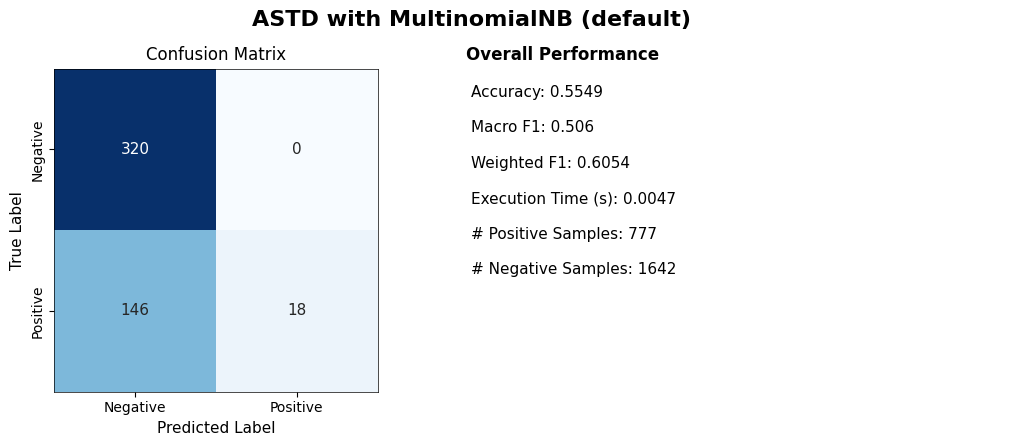



=== Parameter Tuning ===

alpha = 0.0001 → Macro F1 = 0.6848
alpha = 0.001 → Macro F1 = 0.6895
alpha = 0.01 → Macro F1 = 0.6998
alpha = 0.05 → Macro F1 = 0.7016
alpha = 0.1 → Macro F1 = 0.6904
alpha = 0.5 → Macro F1 = 0.582
alpha = 1.0 → Macro F1 = 0.506
alpha = 2.0 → Macro F1 = 0.4301
alpha = 5.0 → Macro F1 = 0.4046
alpha = 10.0 → Macro F1 = 0.398


=== Plot: Macro F1 vs Parameter ===



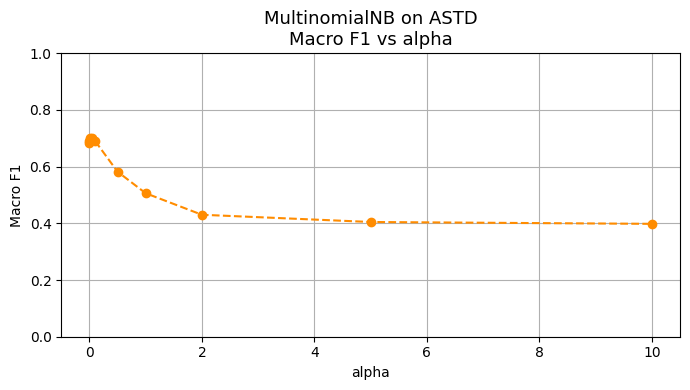



=== Final Run with Best Parameter ===



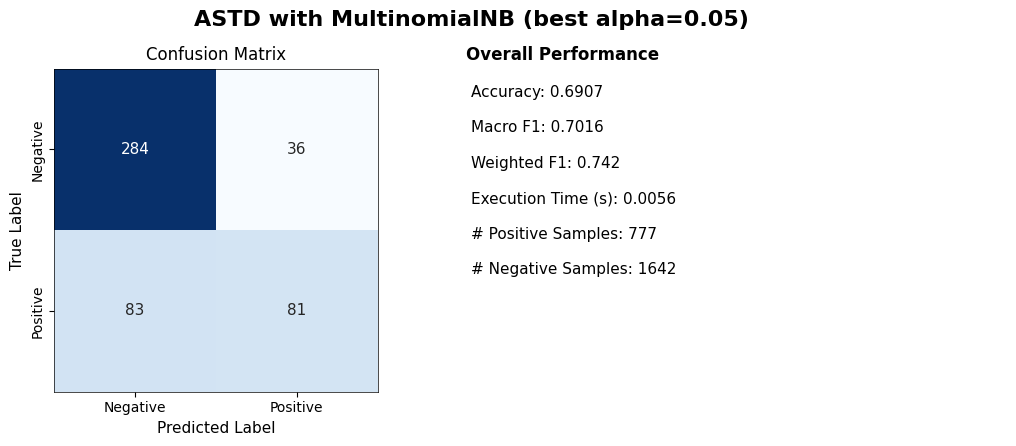



=== Comparison Plot (Horizontal) ===



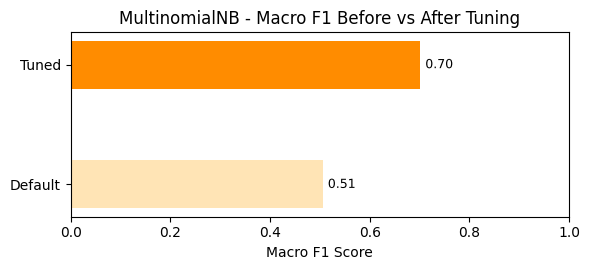

In [62]:
from sklearn.naive_bayes import MultinomialNB

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
MNB_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=MultinomialNB,
    param_name="alpha",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="darkorange",
    lighter_color="moccasin"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([MNB_summary_result])], ignore_index=True)


## **SVM (Linear)**



=== Default Run ===



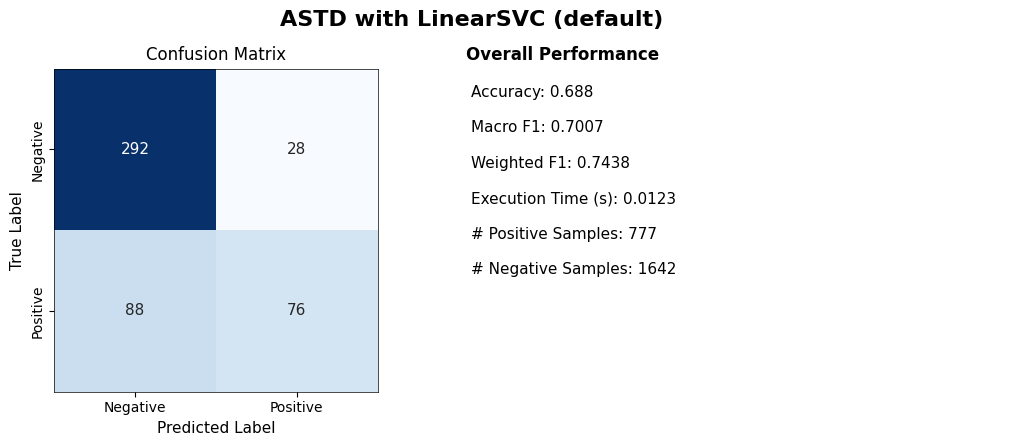



=== Parameter Tuning ===

C = 0.0001 → Macro F1 = 0.398
C = 0.001 → Macro F1 = 0.398
C = 0.01 → Macro F1 = 0.398
C = 0.05 → Macro F1 = 0.4465
C = 0.1 → Macro F1 = 0.5285
C = 1.0 → Macro F1 = 0.7007
C = 5.0 → Macro F1 = 0.7229
C = 10.0 → Macro F1 = 0.7221
C = 20.0 → Macro F1 = 0.7171
C = 50.0 → Macro F1 = 0.7202


=== Plot: Macro F1 vs Parameter ===



/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


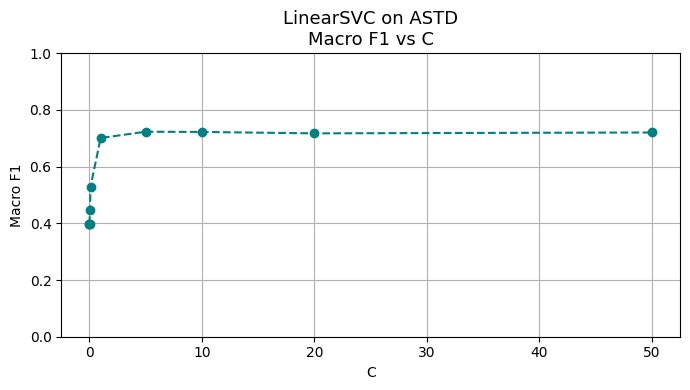



=== Final Run with Best Parameter ===



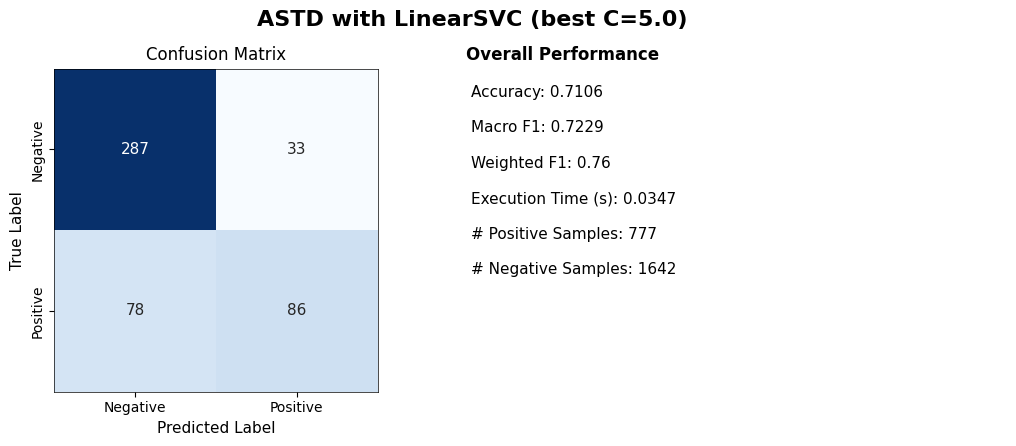



=== Comparison Plot (Horizontal) ===



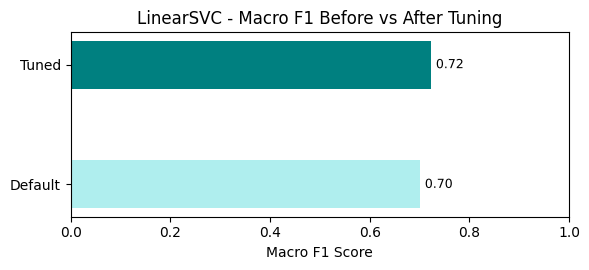

In [63]:
from sklearn.svm import LinearSVC

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]
SVM_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=LinearSVC,
    param_name="C",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="teal",
    lighter_color="paleturquoise"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([SVM_summary_result])], ignore_index=True)


## **LogisticRegression**



=== Default Run ===



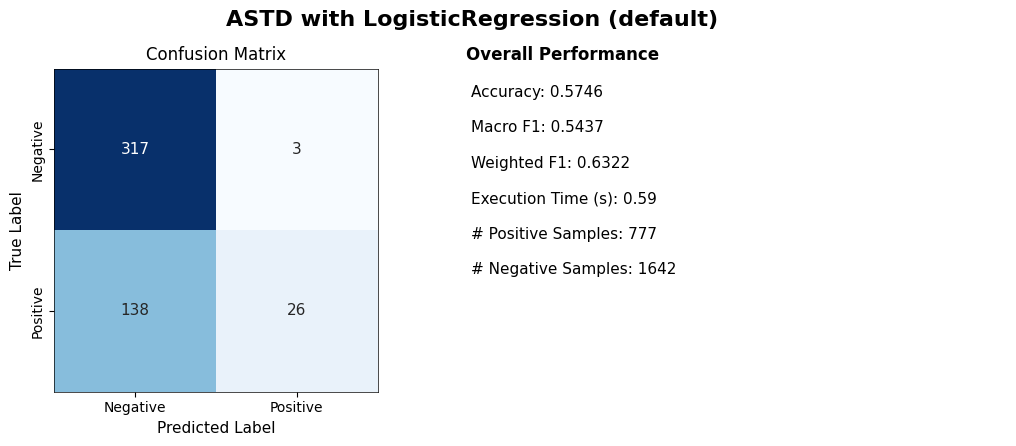



=== Parameter Tuning ===

C = 0.0001 → Macro F1 = 0.398
C = 0.001 → Macro F1 = 0.398
C = 0.01 → Macro F1 = 0.398
C = 0.1 → Macro F1 = 0.398
C = 0.5 → Macro F1 = 0.4631
C = 1.0 → Macro F1 = 0.5437
C = 5.0 → Macro F1 = 0.6585
C = 10.0 → Macro F1 = 0.6742
C = 20.0 → Macro F1 = 0.686
C = 50.0 → Macro F1 = 0.6988


=== Plot: Macro F1 vs Parameter ===



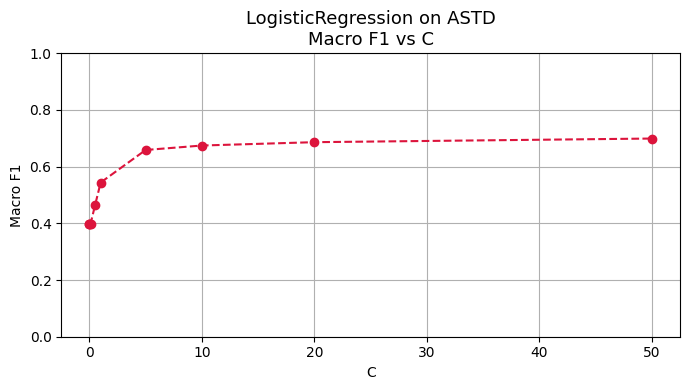



=== Final Run with Best Parameter ===



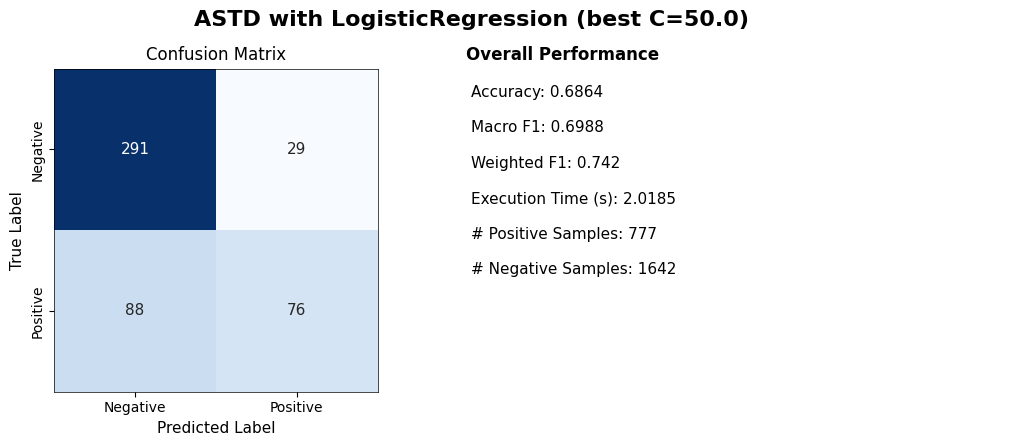



=== Comparison Plot (Horizontal) ===



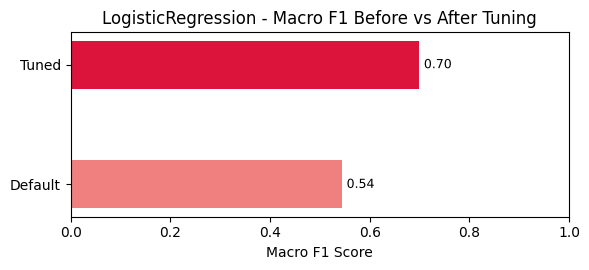

In [64]:
from sklearn.linear_model import LogisticRegression

param_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]
LogReg_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=LogisticRegression,
    param_name="C",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="crimson",
    lighter_color="lightcoral"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([LogReg_summary_result])], ignore_index=True)


## **RandomForest**



=== Default Run ===



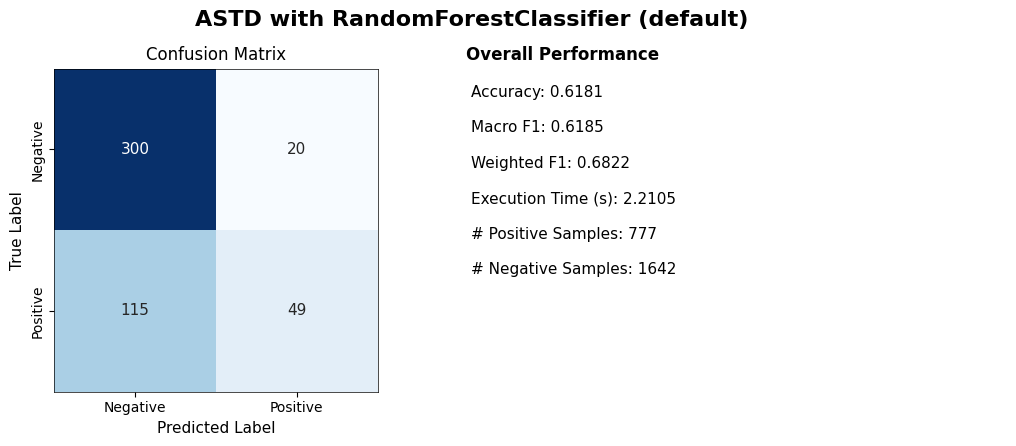



=== Parameter Tuning ===

n_estimators = 10 → Macro F1 = 0.5349
n_estimators = 20 → Macro F1 = 0.625
n_estimators = 50 → Macro F1 = 0.6263
n_estimators = 75 → Macro F1 = 0.6149
n_estimators = 100 → Macro F1 = 0.6396
n_estimators = 150 → Macro F1 = 0.6179
n_estimators = 200 → Macro F1 = 0.619
n_estimators = 300 → Macro F1 = 0.6246
n_estimators = 400 → Macro F1 = 0.634
n_estimators = 500 → Macro F1 = 0.6241


=== Plot: Macro F1 vs Parameter ===



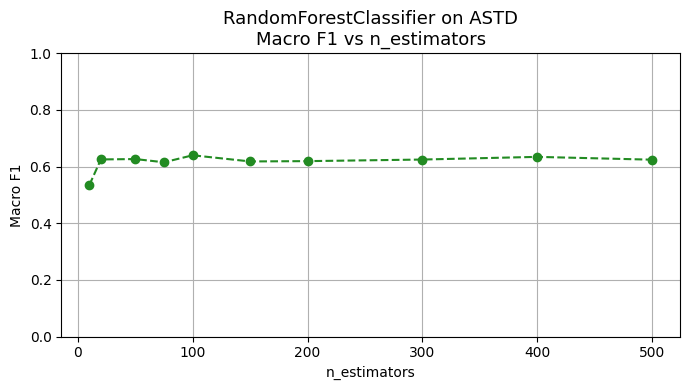



=== Final Run with Best Parameter ===



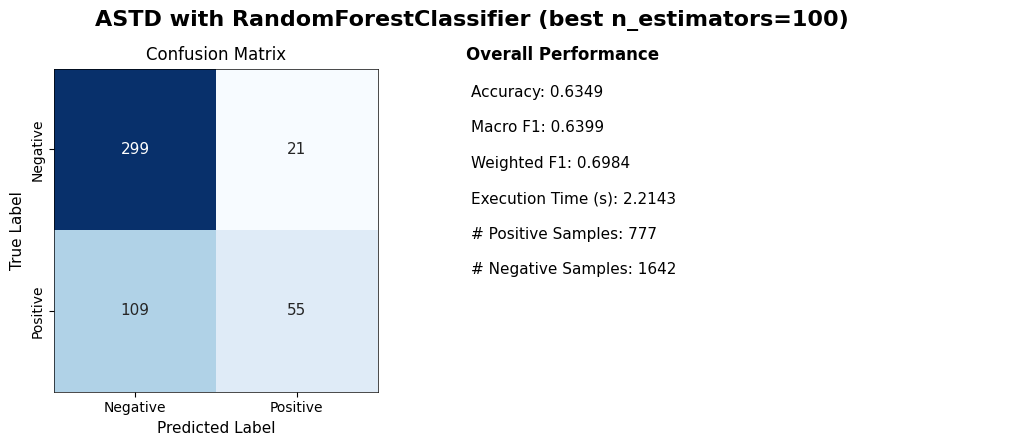



=== Comparison Plot (Horizontal) ===



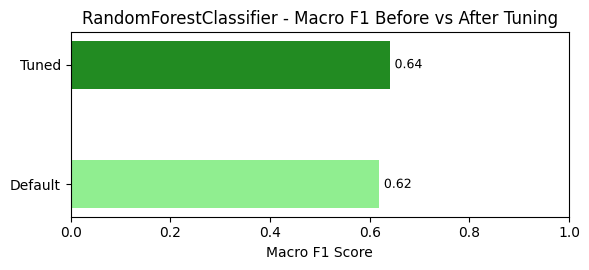

In [65]:
from sklearn.ensemble import RandomForestClassifier

param_values = [10, 20, 50, 75, 100, 150, 200, 300, 400, 500]
RF_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=RandomForestClassifier,
    param_name="n_estimators",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="forestgreen",
    lighter_color="lightgreen"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([RF_summary_result])], ignore_index=True)


## **KNeighborsClassifier**



=== Default Run ===



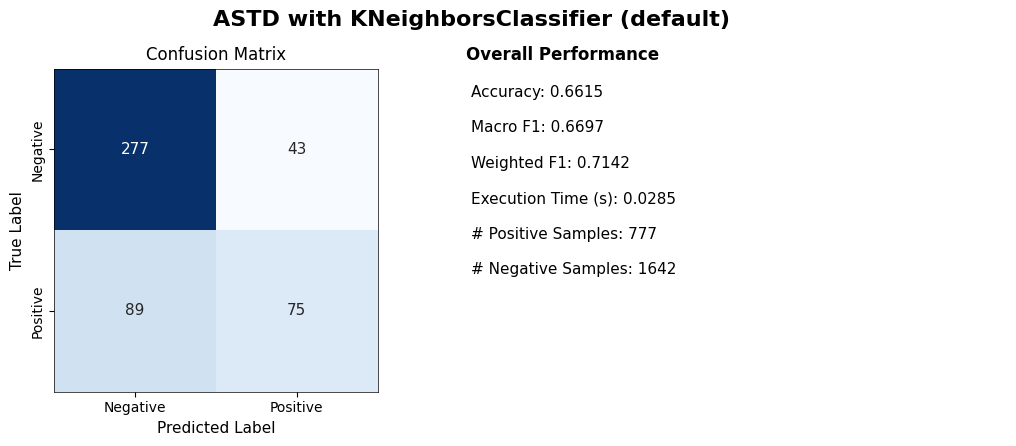



=== Parameter Tuning ===

n_neighbors = 1 → Macro F1 = 0.6815
n_neighbors = 3 → Macro F1 = 0.7118
n_neighbors = 5 → Macro F1 = 0.6697
n_neighbors = 7 → Macro F1 = 0.6625
n_neighbors = 9 → Macro F1 = 0.6475
n_neighbors = 11 → Macro F1 = 0.6442
n_neighbors = 15 → Macro F1 = 0.6528
n_neighbors = 20 → Macro F1 = 0.6076
n_neighbors = 30 → Macro F1 = 0.5807
n_neighbors = 50 → Macro F1 = 0.5358


=== Plot: Macro F1 vs Parameter ===



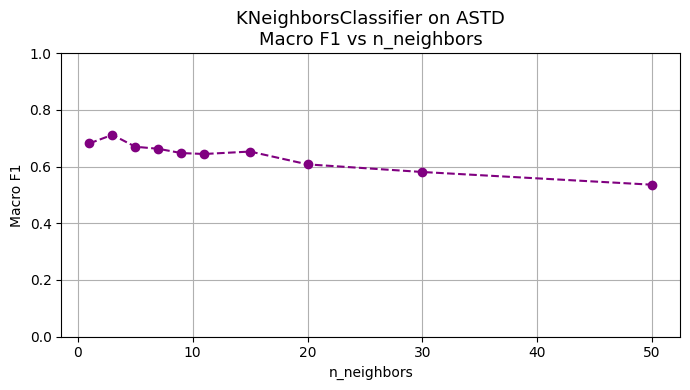



=== Final Run with Best Parameter ===



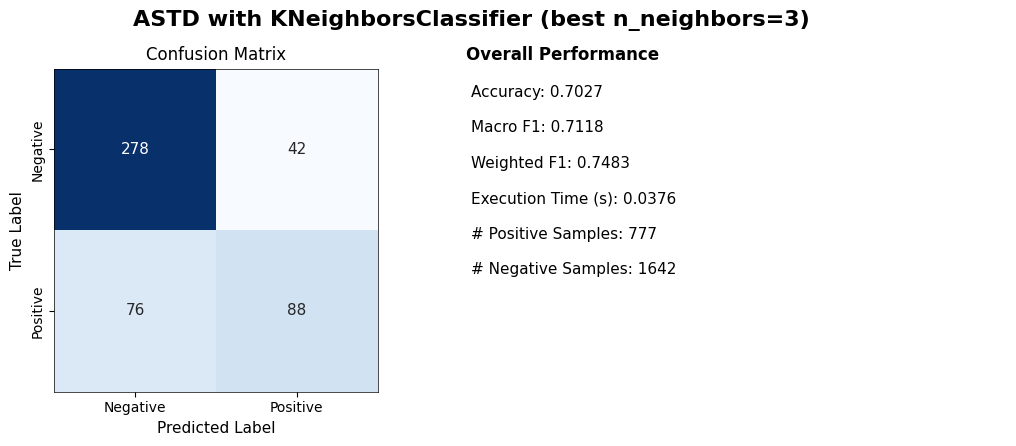



=== Comparison Plot (Horizontal) ===



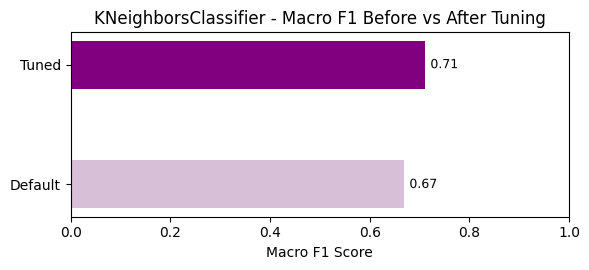

In [66]:
from sklearn.neighbors import KNeighborsClassifier

param_values = [1, 3, 5, 7, 9, 11, 15, 20, 30, 50]
KNN_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=KNeighborsClassifier,
    param_name="n_neighbors",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="purple",
    lighter_color="thistle"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([KNN_summary_result])], ignore_index=True)


## **AdaBoostClassifier**



=== Default Run ===



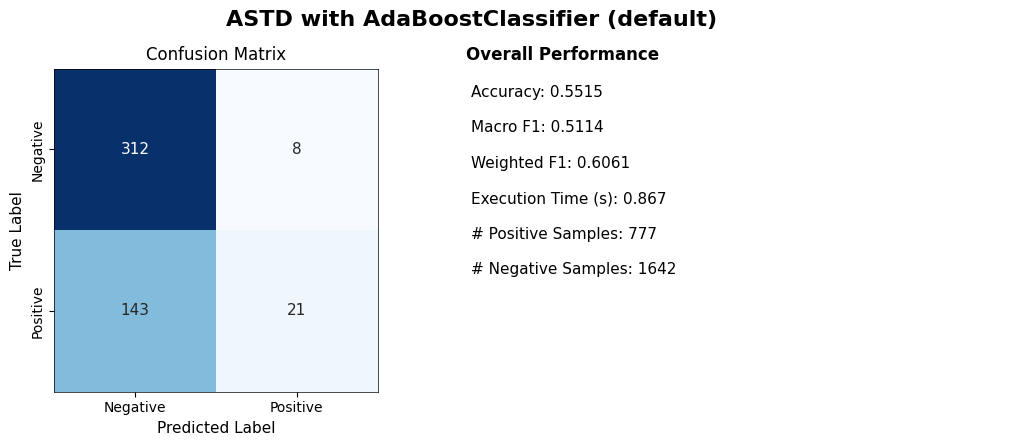



=== Parameter Tuning ===

n_estimators = 10 → Macro F1 = 0.5165
n_estimators = 20 → Macro F1 = 0.5165
n_estimators = 30 → Macro F1 = 0.5114
n_estimators = 50 → Macro F1 = 0.5114
n_estimators = 75 → Macro F1 = 0.5414
n_estimators = 100 → Macro F1 = 0.5379
n_estimators = 150 → Macro F1 = 0.5379
n_estimators = 200 → Macro F1 = 0.5394
n_estimators = 250 → Macro F1 = 0.5429
n_estimators = 300 → Macro F1 = 0.5492


=== Plot: Macro F1 vs Parameter ===



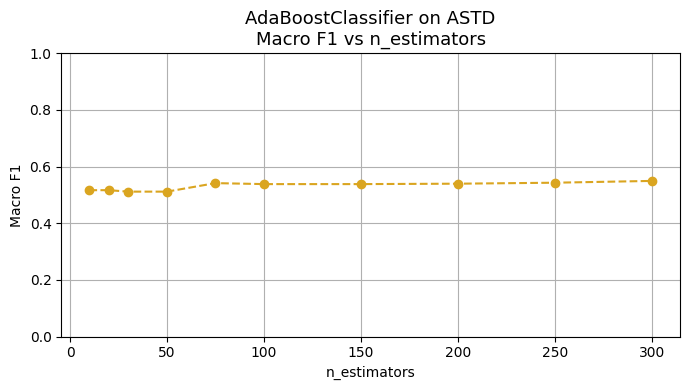



=== Final Run with Best Parameter ===



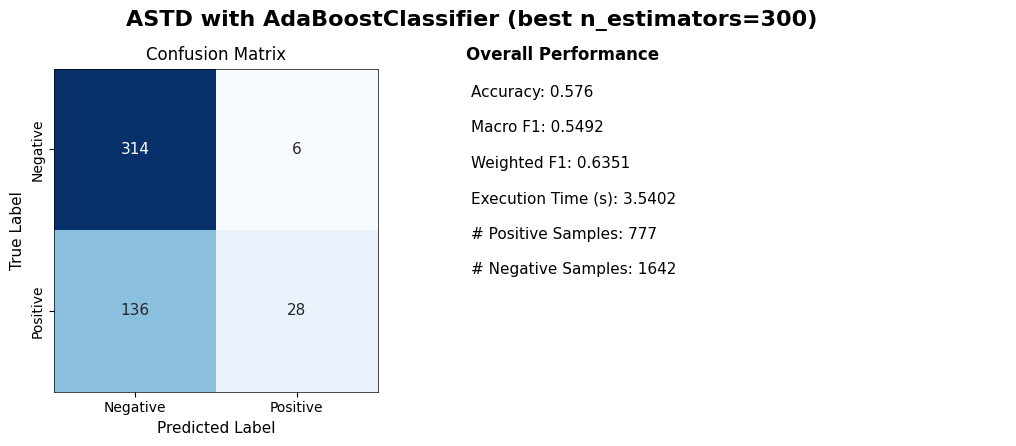



=== Comparison Plot (Horizontal) ===



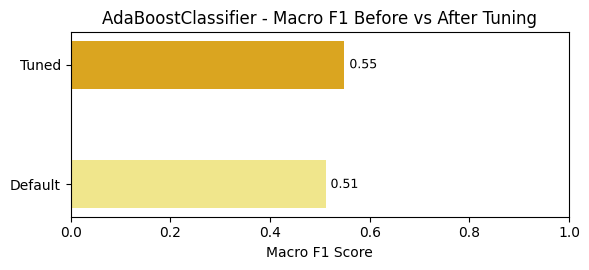

In [67]:
from sklearn.ensemble import AdaBoostClassifier

param_values = [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
AdaBoost_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=AdaBoostClassifier,
    param_name="n_estimators",
    param_values=param_values,
    dataset_label="ASTD",
    base_color="goldenrod",
    lighter_color="khaki"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([AdaBoost_summary_result])], ignore_index=True)


## **All results**

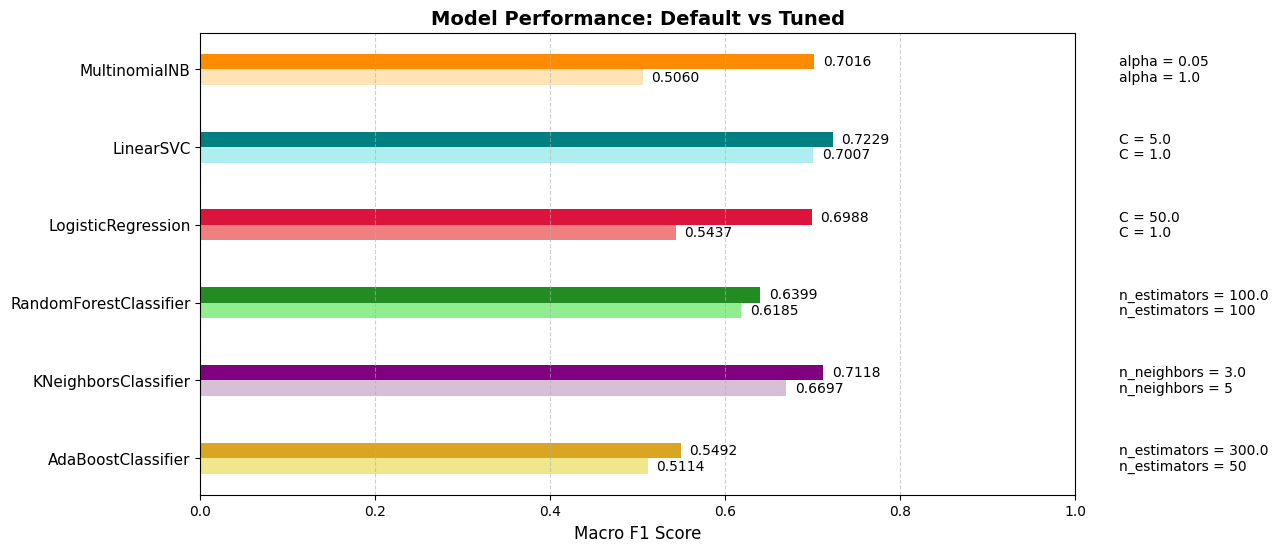

In [68]:
plot_all_models_comparison(all_summary_results)

# ASTD - 8 algorithmes test

In [53]:
all_Algo_results = pd.DataFrame()

## **Multinomial Naive Bayes**


🔎 Evaluating MultinomialNB with param: alpha ∈ [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

🚀 Running MultinomialNB on ASTD...
⚡ Testing for MultinomialNB on ASTD...
✅ Best alpha = 0.05 → Macro F1: 0.7016
📦 Model saved to: models/MultinomialNB_ASTD_best.pkl


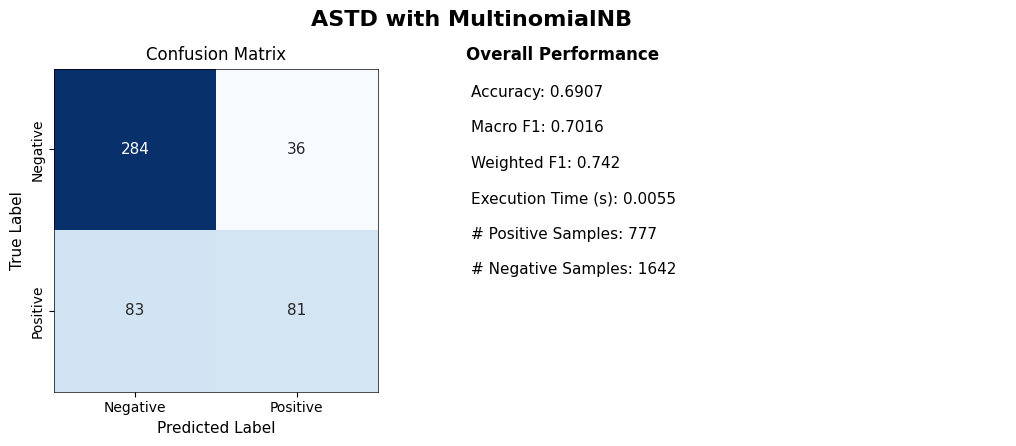


🚀 Running MultinomialNB on ASTD_Preprocessed...
⚡ Testing for MultinomialNB on ASTD_Preprocessed...
✅ Best alpha = 0.1 → Macro F1: 0.7085
📦 Model saved to: models/MultinomialNB_ASTD_Preprocessed_best.pkl


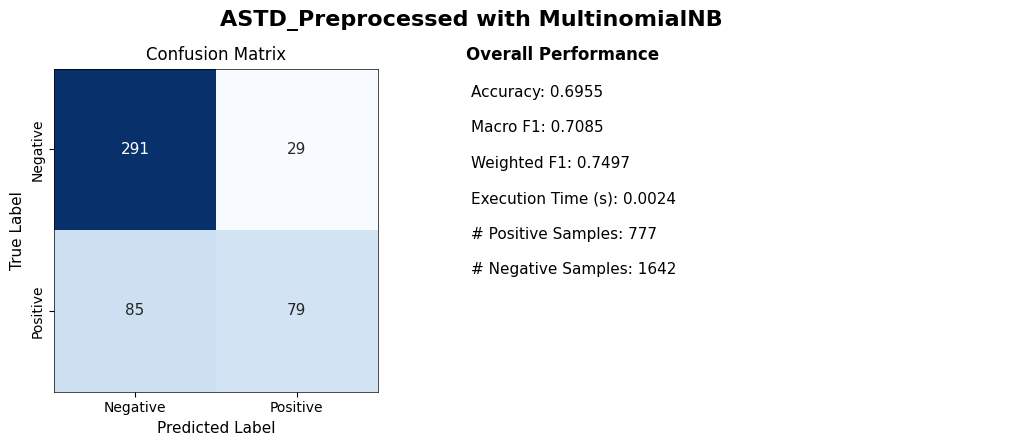


🚀 Running MultinomialNB on ASTD_Preprocessed_Balanced...
⚡ Testing for MultinomialNB on ASTD_Preprocessed_Balanced...
✅ Best alpha = 0.5 → Macro F1: 0.8886
📦 Model saved to: models/MultinomialNB_ASTD_Preprocessed_Balanced_best.pkl


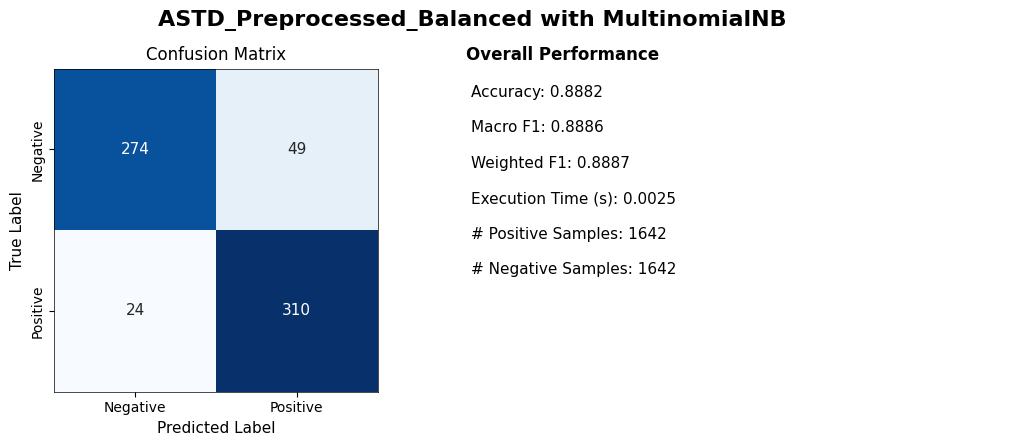

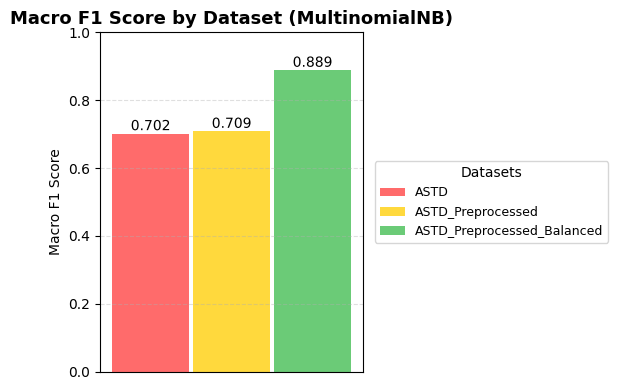

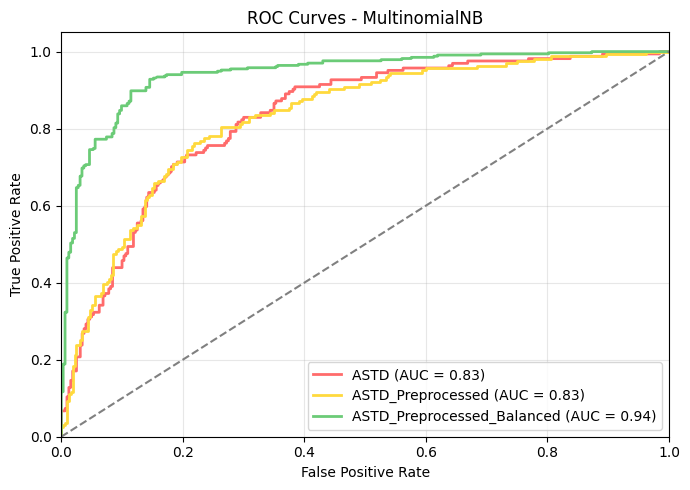

In [54]:
from sklearn.naive_bayes import MultinomialNB

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

MNB_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=MultinomialNB,
    param_name="alpha",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, MNB_results], ignore_index=True)

## **SVM (Linear)**


🔎 Evaluating LinearSVC with param: C ∈ [0.0001, 0.001, 0.01, 0.05, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]

🚀 Running LinearSVC on ASTD...
⚡ Testing for LinearSVC on ASTD...
✅ Best C = 20.0 → Macro F1: 0.7198
📦 Model saved to: models/LinearSVC_ASTD_best.pkl


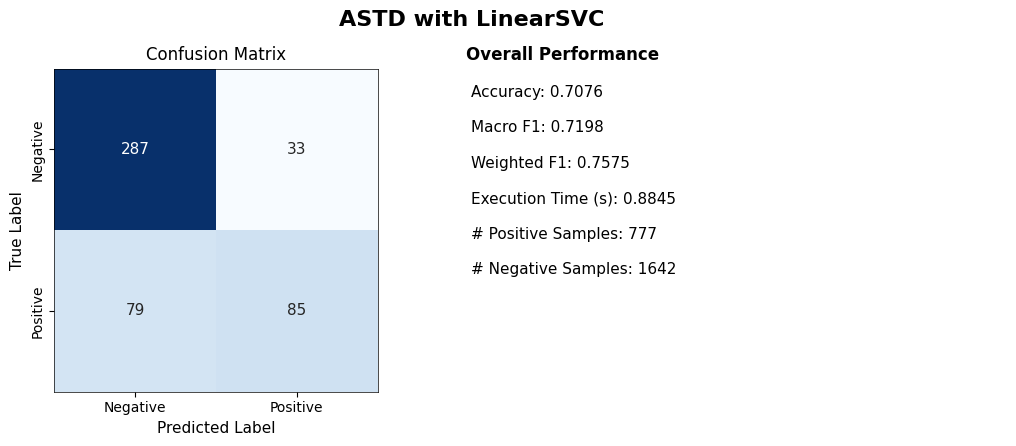


🚀 Running LinearSVC on ASTD_Preprocessed...
⚡ Testing for LinearSVC on ASTD_Preprocessed...
✅ Best C = 0.1 → Macro F1: 0.7440
📦 Model saved to: models/LinearSVC_ASTD_Preprocessed_best.pkl


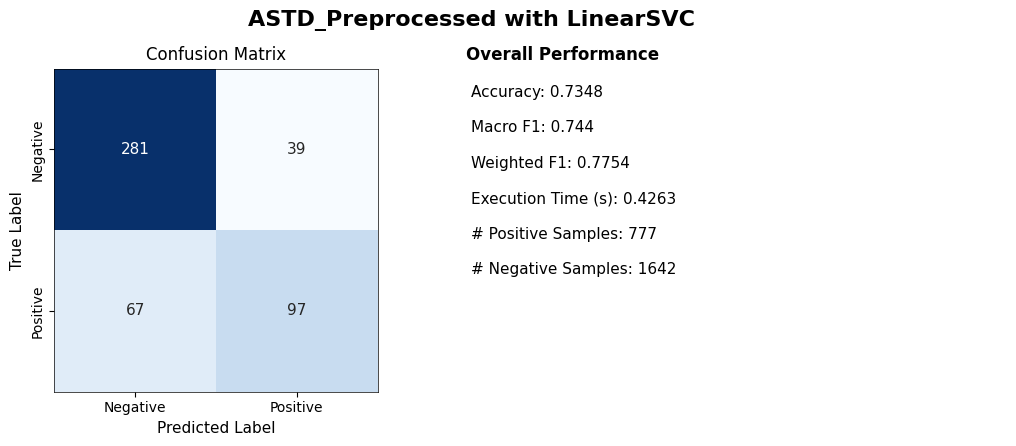


🚀 Running LinearSVC on ASTD_Preprocessed_Balanced...
⚡ Testing for LinearSVC on ASTD_Preprocessed_Balanced...
✅ Best C = 1.0 → Macro F1: 0.8782
📦 Model saved to: models/LinearSVC_ASTD_Preprocessed_Balanced_best.pkl


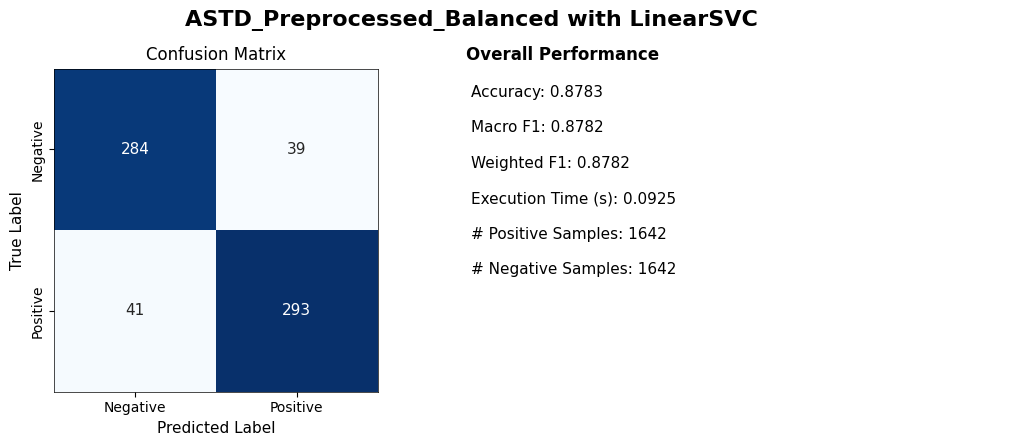

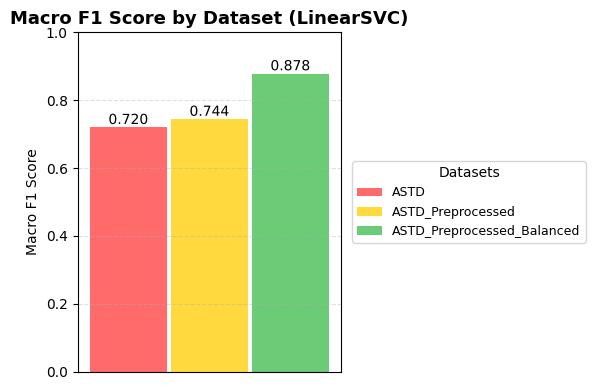

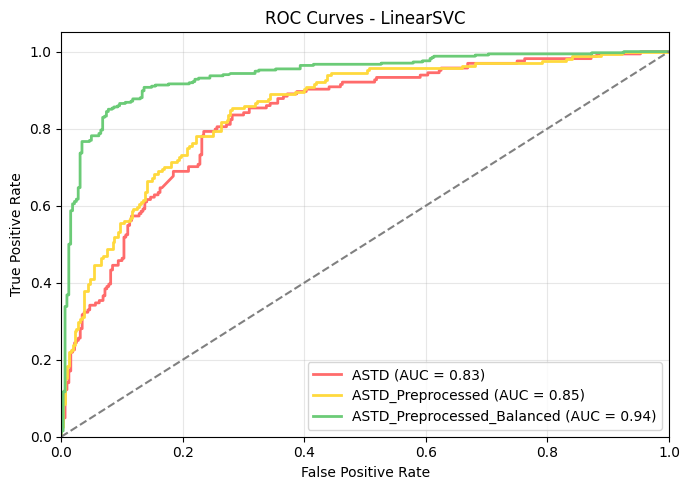

In [55]:
from sklearn.svm import LinearSVC

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]

SVM_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=LinearSVC,
    param_name="C",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, SVM_results], ignore_index=True)

## **LogisticRegression**


🔎 Evaluating LogisticRegression with param: C ∈ [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]

🚀 Running LogisticRegression on ASTD...
⚡ Testing for LogisticRegression on ASTD...
✅ Best C = 50.0 → Macro F1: 0.6988
📦 Model saved to: models/LogisticRegression_ASTD_best.pkl


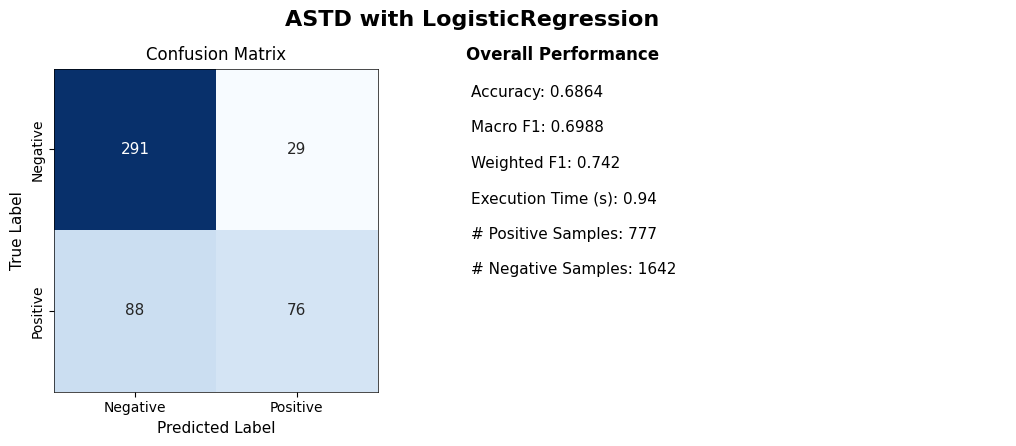


🚀 Running LogisticRegression on ASTD_Preprocessed...
⚡ Testing for LogisticRegression on ASTD_Preprocessed...
✅ Best C = 5.0 → Macro F1: 0.7419
📦 Model saved to: models/LogisticRegression_ASTD_Preprocessed_best.pkl


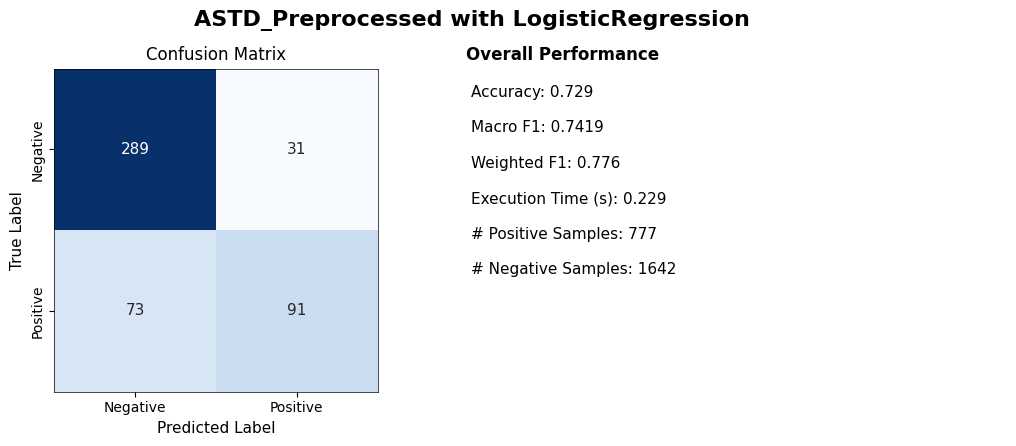


🚀 Running LogisticRegression on ASTD_Preprocessed_Balanced...
⚡ Testing for LogisticRegression on ASTD_Preprocessed_Balanced...
✅ Best C = 5.0 → Macro F1: 0.8857
📦 Model saved to: models/LogisticRegression_ASTD_Preprocessed_Balanced_best.pkl


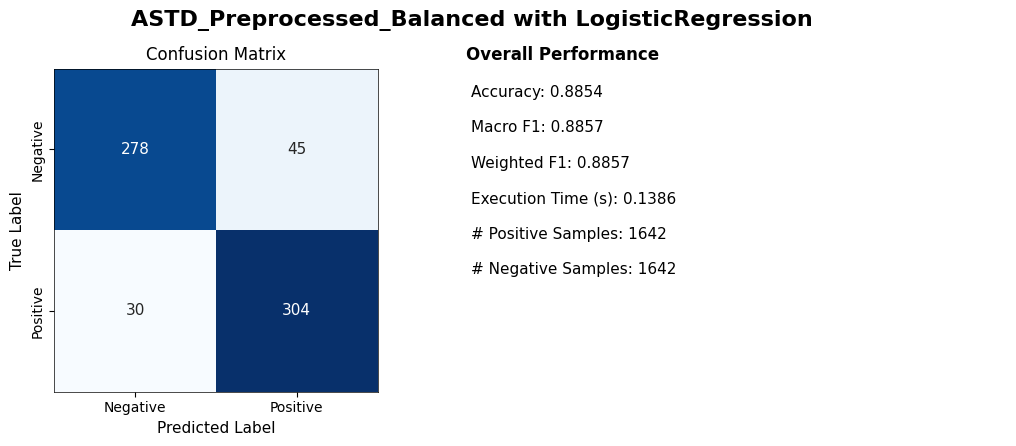

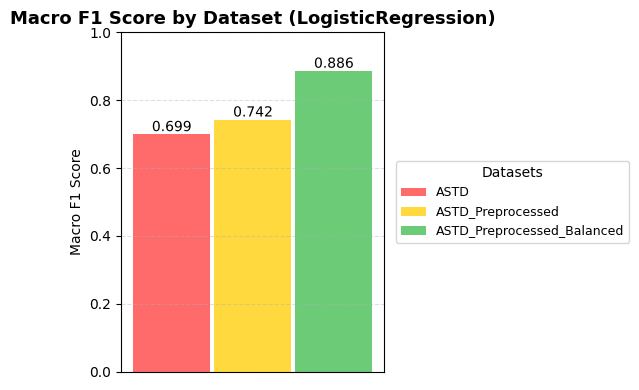

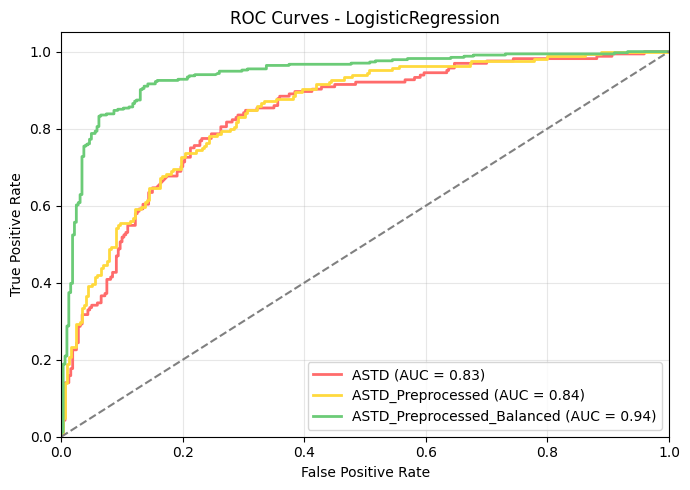

In [56]:
from sklearn.linear_model import LogisticRegression

param_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]

LogReg_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=LogisticRegression,
    param_name="C",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, LogReg_results], ignore_index=True)

## **RandomForest**


🔎 Evaluating RandomForestClassifier with param: n_estimators ∈ [10, 20, 50, 75, 100, 150, 200, 300, 400, 500]

🚀 Running RandomForestClassifier on ASTD...
⚡ Testing for RandomForestClassifier on ASTD...
✅ Best n_estimators = 100 → Macro F1: 0.6340
📦 Model saved to: models/RandomForestClassifier_ASTD_best.pkl


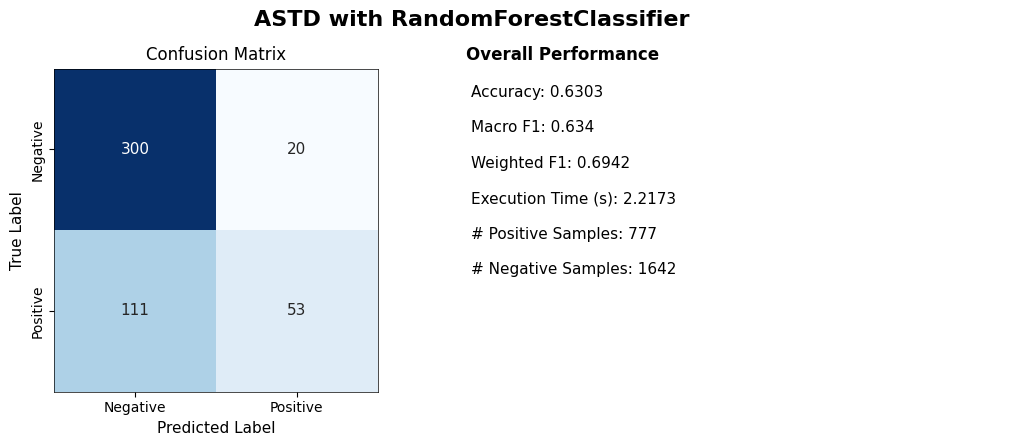


🚀 Running RandomForestClassifier on ASTD_Preprocessed...
⚡ Testing for RandomForestClassifier on ASTD_Preprocessed...
✅ Best n_estimators = 50 → Macro F1: 0.7341
📦 Model saved to: models/RandomForestClassifier_ASTD_Preprocessed_best.pkl


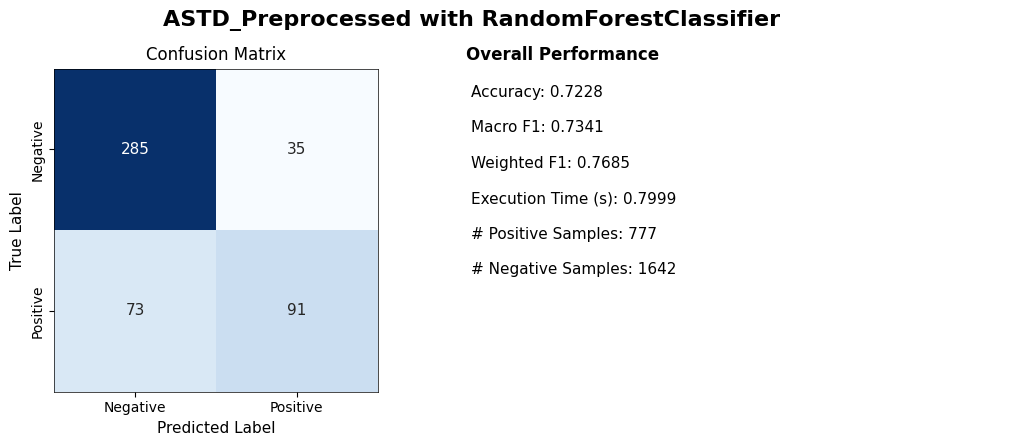


🚀 Running RandomForestClassifier on ASTD_Preprocessed_Balanced...
⚡ Testing for RandomForestClassifier on ASTD_Preprocessed_Balanced...
✅ Best n_estimators = 100 → Macro F1: 0.8978
📦 Model saved to: models/RandomForestClassifier_ASTD_Preprocessed_Balanced_best.pkl


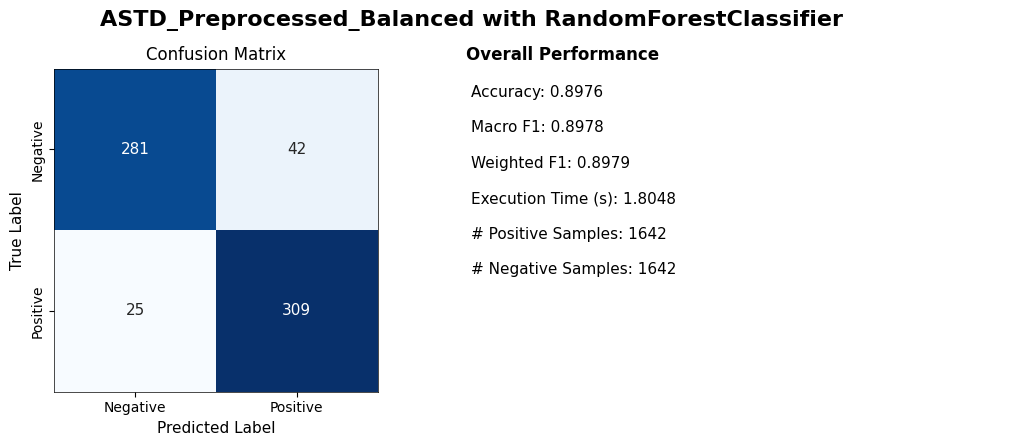

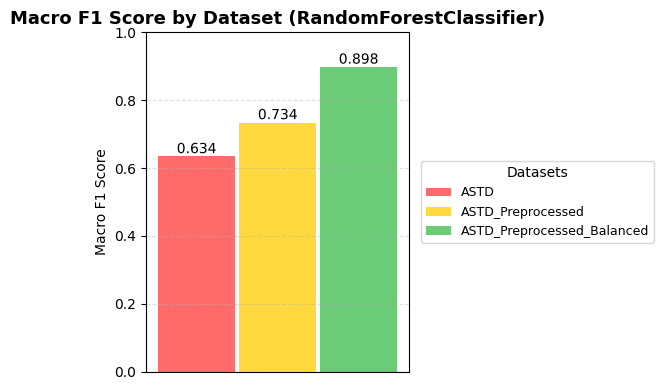

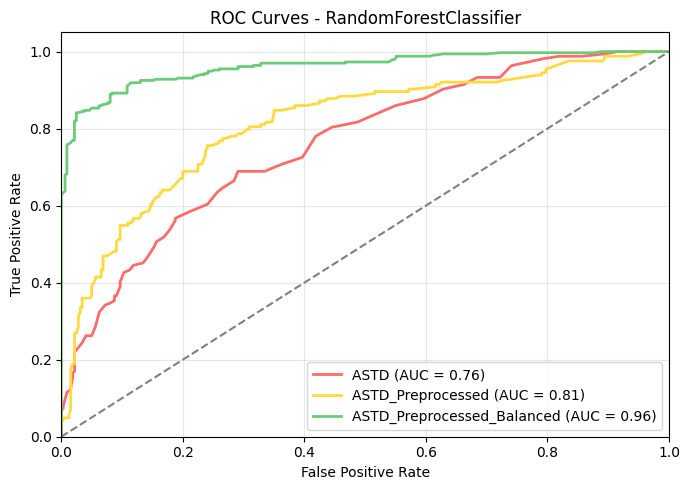

In [57]:
from sklearn.ensemble import RandomForestClassifier

param_values = [10, 20, 50, 75, 100, 150, 200, 300, 400, 500]

RF_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=RandomForestClassifier,
    param_name="n_estimators",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, RF_results], ignore_index=True)

## **KNeighborsClassifier**


🔎 Evaluating KNeighborsClassifier with param: n_neighbors ∈ [1, 3, 5, 7, 9, 11, 15, 20, 30, 50]

🚀 Running KNeighborsClassifier on ASTD...
⚡ Testing for KNeighborsClassifier on ASTD...
✅ Best n_neighbors = 3 → Macro F1: 0.7118
📦 Model saved to: models/KNeighborsClassifier_ASTD_best.pkl


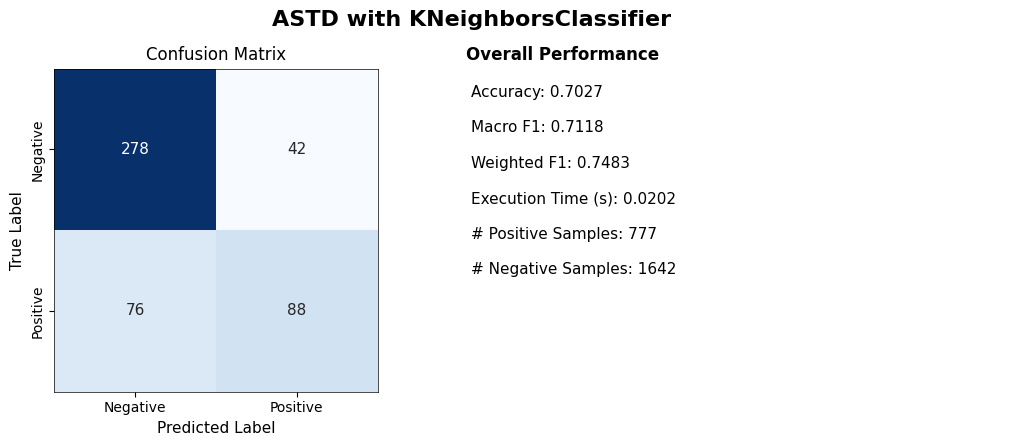


🚀 Running KNeighborsClassifier on ASTD_Preprocessed...
⚡ Testing for KNeighborsClassifier on ASTD_Preprocessed...
✅ Best n_neighbors = 15 → Macro F1: 0.7259
📦 Model saved to: models/KNeighborsClassifier_ASTD_Preprocessed_best.pkl


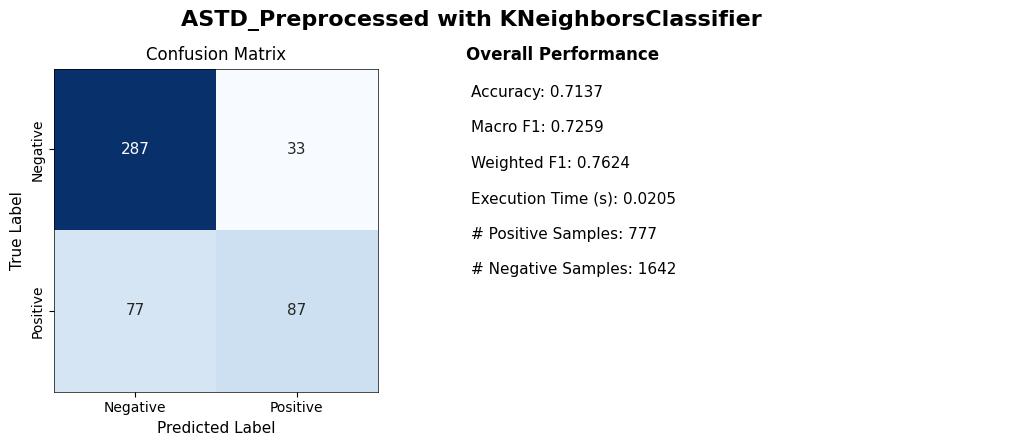


🚀 Running KNeighborsClassifier on ASTD_Preprocessed_Balanced...
⚡ Testing for KNeighborsClassifier on ASTD_Preprocessed_Balanced...
✅ Best n_neighbors = 3 → Macro F1: 0.8100
📦 Model saved to: models/KNeighborsClassifier_ASTD_Preprocessed_Balanced_best.pkl


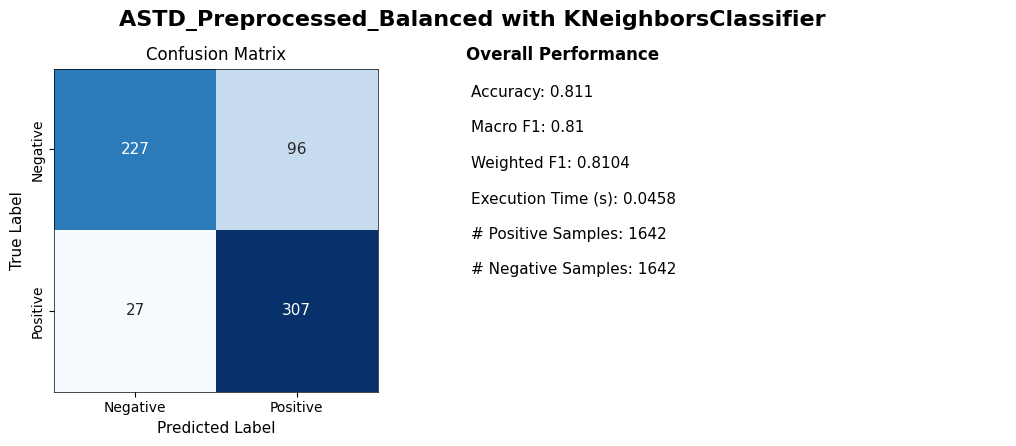

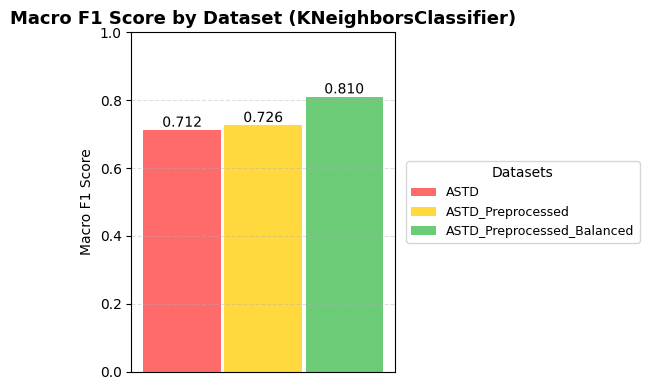

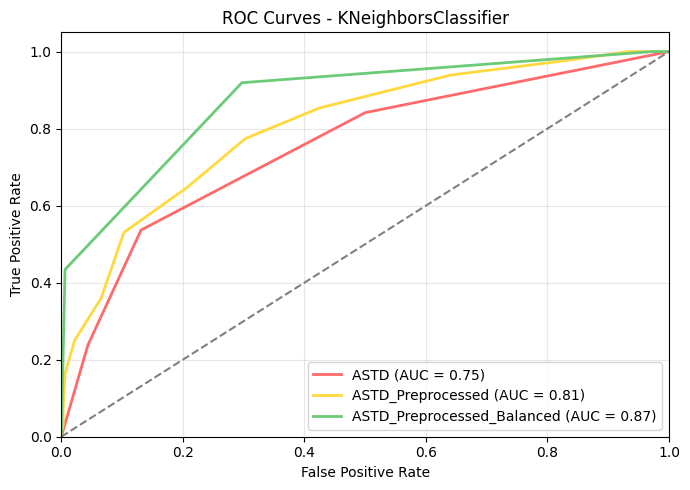

In [58]:
from sklearn.neighbors import KNeighborsClassifier

param_values = [1, 3, 5, 7, 9, 11, 15, 20, 30, 50]

KNN_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=KNeighborsClassifier,
    param_name="n_neighbors",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, KNN_results], ignore_index=True)

## **AdaBoostClassifier**


🔎 Evaluating AdaBoostClassifier with param: n_estimators ∈ [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]

🚀 Running AdaBoostClassifier on ASTD...
⚡ Testing for AdaBoostClassifier on ASTD...
✅ Best n_estimators = 300 → Macro F1: 0.5492
📦 Model saved to: models/AdaBoostClassifier_ASTD_best.pkl


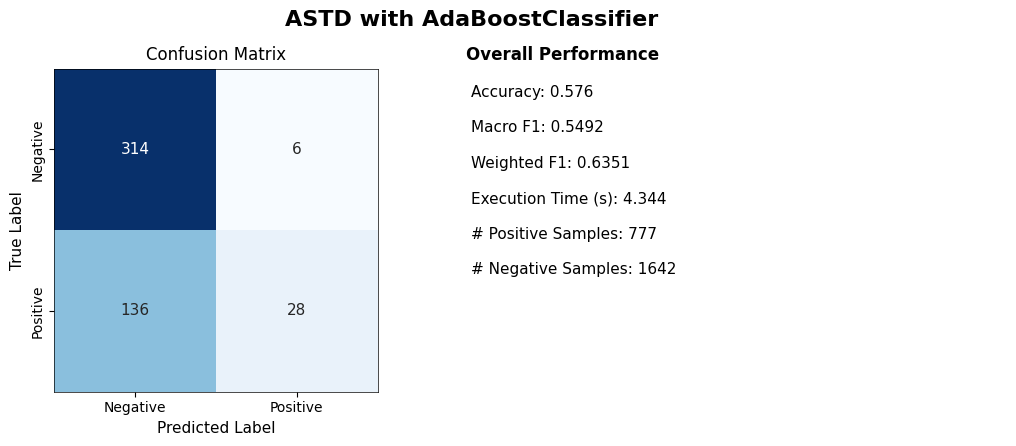


🚀 Running AdaBoostClassifier on ASTD_Preprocessed...
⚡ Testing for AdaBoostClassifier on ASTD_Preprocessed...
✅ Best n_estimators = 300 → Macro F1: 0.6024
📦 Model saved to: models/AdaBoostClassifier_ASTD_Preprocessed_best.pkl


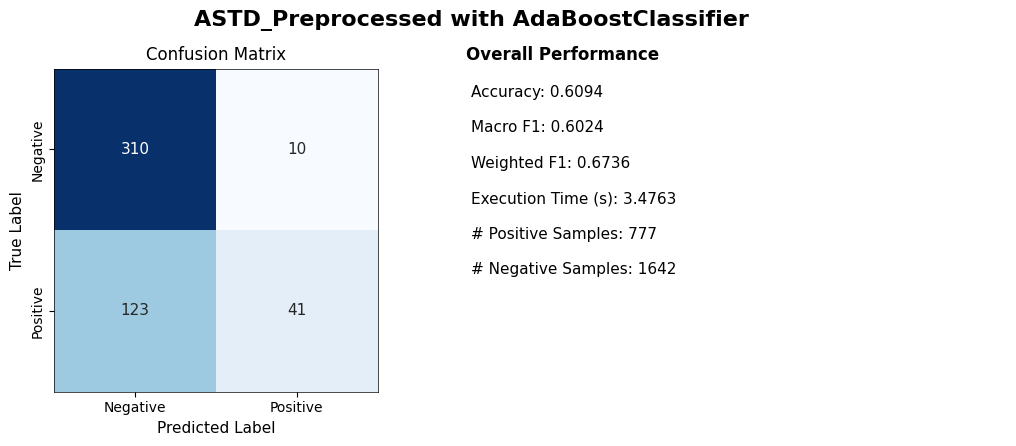


🚀 Running AdaBoostClassifier on ASTD_Preprocessed_Balanced...
⚡ Testing for AdaBoostClassifier on ASTD_Preprocessed_Balanced...
✅ Best n_estimators = 300 → Macro F1: 0.7232
📦 Model saved to: models/AdaBoostClassifier_ASTD_Preprocessed_Balanced_best.pkl


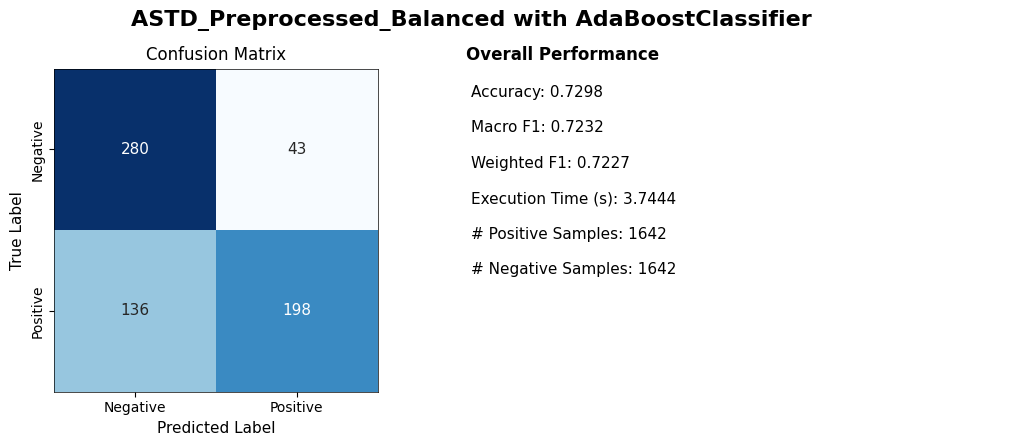

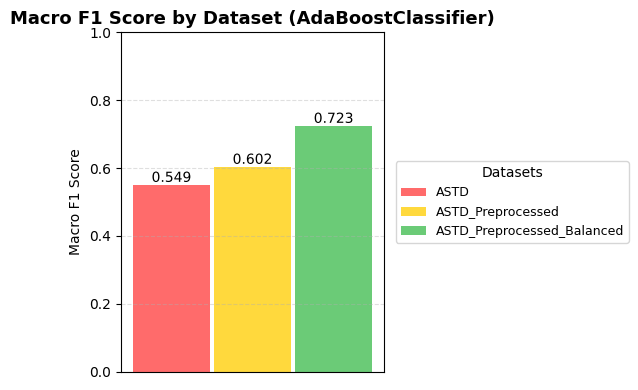

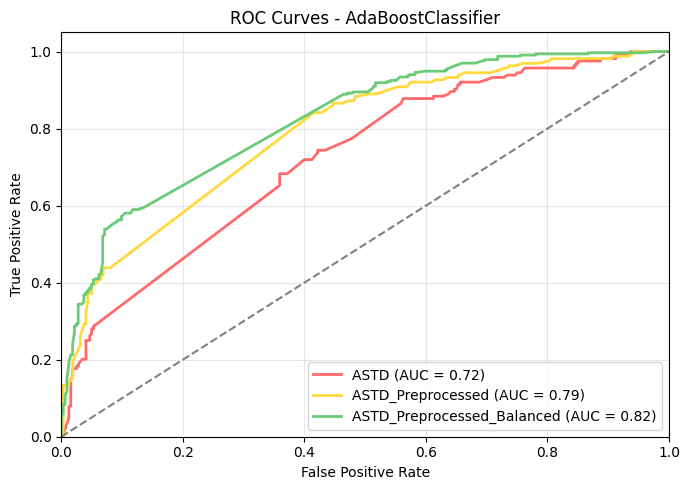

In [59]:
from sklearn.ensemble import AdaBoostClassifier

param_values = [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]

AdaBoost_results = evaluate_model_with_plot(
    datasets=datasets,
    model_class=AdaBoostClassifier,
    param_name="n_estimators",
    param_values=param_values
)

all_Algo_results = pd.concat([all_Algo_results, AdaBoost_results], ignore_index=True)

## **All results**

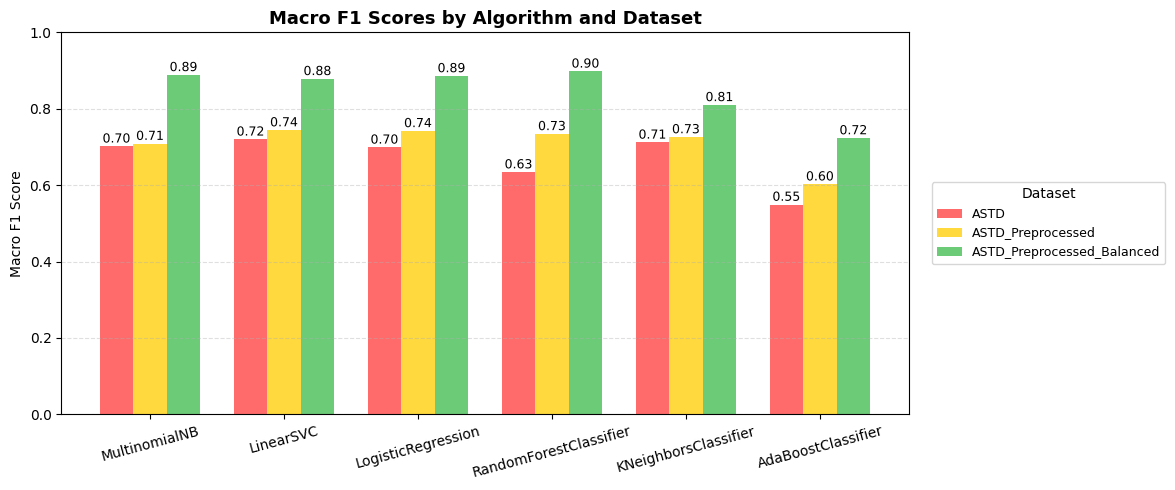

📄 Saved: results/results_summary.csv


In [60]:
plot_grouped_macro_f1(
    all_results=all_Algo_results,
    datasets=["ASTD", "ASTD_Preprocessed", "ASTD_Preprocessed_Balanced"]
)
